[<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> 1. Completed Level](https://colab.research.google.com/github/AlbertoLopezCorbalan/MIA-TFM/blob/main/TFM_completed_level.ipynb)  

# Trabajo Fin de Máster - Completed Level
> Autor: Alberto López Corbalán alberto.lopezc@um.es

En muchos problemas de aprendizaje automático supervisado, la disponibilidad de datos etiquetados constituye uno de los principales cuellos de botella. El proceso de anotación suele ser costoso en términos de tiempo, recursos económicos y esfuerzo humano, especialmente cuando requiere conocimiento experto. Por ello, resulta fundamental explorar estrategias que permitan reducir este coste sin comprometer significativamente el rendimiento de los modelos.

Para llevar a cabo este estudio, se parte de un dataset completamente etiquetado que actúa como referencia. En los diversos escenarios, se ocultan las etiquetas de la mayor parte de los datos, simulando un entorno real con escasez de anotaciones. En el caso del Active Learning, las etiquetas se revelan progresivamente bajo demanda del algoritmo.

* Escenario 0 (baseline): este escenario mostrará el límite experimental de nuestro problema.
* Escenario 1 (Machine Learning): mediante el uso de modelos de machine learning, se entrenan y se calculará su rendimiento.
* Escenario 2 (Active Learning): en este escenario se partirá del 10% para entrenamiento, el resto de instancias se seleccionan de forma iterativa mediante estrategias de Active Learning (AL), solicitando etiquetas únicamente para aquellos casos considerados más informativos. Al final también se llegará al mismo 20% del total como en los otros escenarios.
* Escenario 3 (LLMs tabular): al igual que en el primer escenario, se comienza con un 20% de datos etiquetados, pero en este caso se utiliza un modelo del lenguaje de gran tamaño (LLMs) mediante *fine-tuning*.

El objetivo principal es determinar si los escenarios 1, 2 y 3 pueden acercarse al rendimiento del escenario 0, reduciendo significativamente el coste asociado al etiquetado manual. Este enfoque permite evaluar el impacto de distintas estrategias de reducción de etiquetado. Para llevar a cabo nuestro trabajo segmentaremos el notebook en los siguientes apartados:

0. [Configuración inicial](#0)  
1. [Preprocesamiento y análisis del conjunto de datos](#1)  
2. [Entrenamiento con dataset completamente etiquetado (límite experimental)](#2)
3. [Modelos clásicos de Machine Learning](#3)  
4. [Estrategias de Active Learning](#4)  
5. [Fine-tuning de un modelo LLM](#5)  
6. [Análisis de resultados y conclusiones](#6)  

# 0. Configuración inicial <a id="0"></a>

In [1]:
# Framework modAL
!pip install modAL-python
!pip install tabpfn

In [2]:
import sys

if "google.colab" in sys.modules:
    print("Google Colab")
    # Para obtener el dataset si se ejecuta en Colab
    !git clone https://github.com/AlbertoLopezCorbalan/MIA-TFM
    %cd MIA-TFM

Google Colab
fatal: destination path 'MIA-TFM' already exists and is not an empty directory.
/content/MIA-TFM


In [3]:
import pandas as pd
import re
import numpy as np
import json
import matplotlib.pyplot as plt
import time
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import make_scorer, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
import warnings

# Active Learning
from sklearn.ensemble import RandomForestClassifier
from modAL.models import ActiveLearner, Committee
from modAL.uncertainty import uncertainty_sampling
from modAL.disagreement import vote_entropy_sampling
from scipy.ndimage import uniform_filter1d

# Transfer Learning
from transformers import pipeline
from tabpfn import TabPFNClassifier
import torch
import os

# Solo disponible 90 días, renovarla en https://ux.priorlabs.ai/account/api-keys
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_5yOAvtS2FJ_GHK-i4p7dY18AJwobbxZ868CpVPo-dS4"

GLOBAL_SEED = 123 # Seed global utilizada para garantizar la reproducibilidad
DATASET_PATH = "dataset/complete_report_features_and_text_replay.csv"

# 1. Preprocesamiento y análisis conjunto de datos <a id="1"></a>

El conjunto de datos utilizado en este trabajo proviene de un juego de puzles 3D denominado *Shadowpect*. En este juego, los usuarios deben construir una figura geométrica compleja a partir de elementos más simples (cubos, esferas...), utilizando como referencia distintas vistas de la figura objetivo.

Cada instancia del dataset representa una **replay**, es decir, un intento de un jugador por resolver un puzle específico. A partir de estas replays se han definido diferentes grupos de variables que permiten caracterizar tanto el contexto del jugador como su comportamiento durante la resolución del nivel.

In [4]:
dataset = pd.read_csv(DATASET_PATH)
print(f"{DATASET_PATH}: " + str(len(dataset)))
dataset.head()

dataset/complete_report_features_and_text_replay.csv: 6995


,replay,user,group,puzzle,globalAttemptId,attemptId,contextFeatures,attemptFeatures,textReplay
0,2. Separated Boxes~1,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,2. Separated Boxes,2,1,"{""#Attempt"": 1, ""#GlobalAttempt"": 2, ""ActiveTi...","{""ActiveTime"": 27.355294999999998, ""InactiveTi...",Player 2d3db94690a19a62a0942fbd6ac30308 starte...
1,3. Rotate a Pyramid~1,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,3. Rotate a Pyramid,3,1,"{""#Attempt"": 1, ""#GlobalAttempt"": 3, ""ActiveTi...","{""ActiveTime"": 164.38663100000002, ""InactiveTi...",Player 2d3db94690a19a62a0942fbd6ac30308 starte...
2,3. Rotate a Pyramid~2,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,3. Rotate a Pyramid,5,2,"{""#Attempt"": 2, ""#GlobalAttempt"": 5, ""ActiveTi...","{""ActiveTime"": 170.76343800000006, ""InactiveTi...",Player 2d3db94690a19a62a0942fbd6ac30308 starte...
3,Bear Market~1,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,Bear Market,4,1,"{""#Attempt"": 1, ""#GlobalAttempt"": 4, ""ActiveTi...","{""ActiveTime"": 40.556214, ""InactiveTime"": 0, ""...",Player 2d3db94690a19a62a0942fbd6ac30308 starte...
4,4. Match Silhouettes~1,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,4. Match Silhouettes,6,1,"{""#Attempt"": 1, ""#GlobalAttempt"": 6, ""ActiveTi...","{""ActiveTime"": 100.48931000000002, ""InactiveTi...",Player 2d3db94690a19a62a0942fbd6ac30308 starte...


Algunas de las variables del dataset se encuentran originalmente almacenadas como estructuras en formato JSON serializado (cadenas de texto). Este tipo de representación, aunque flexible para el almacenamiento, no es directamente utilizable por la mayoría de algoritmos de *Machine Learning*, que requieren datos tabulares.

Por este motivo, se lleva a cabo un proceso de **aplanado (*flattening*) de las estructuras JSON**, cuyo objetivo es transformar cada campo anidado en un conjunto de variables independientes.

Se omiten las variables *contextFeatures*, *attemptId* y *globalAttemptId*, ya que contienen información global del usuario (como el número de niveles completados previamente). Dado que el objetivo del modelo es predecir si un intento concreto se completa o no utilizando únicamente información del propio nivel, estas variables se omiten.

In [5]:
df_preprocessed = dataset.copy(deep = True)

# Parseamos el json
df_preprocessed["attemptFeatures"] = df_preprocessed["attemptFeatures"].apply(json.loads)

# Normalizamos los json para pasarlos a una tabla aplanada
df_attempt = pd.json_normalize(df_preprocessed["attemptFeatures"])

# Quitamos los "." por "_"
df_attempt.columns = df_attempt.columns.str.replace(".", "_", regex=False)

# Unimos todo
df_preprocessed = pd.concat(
    [
        df_preprocessed.drop(columns=["contextFeatures", "globalAttemptId", "attemptId", "attemptFeatures"]),
        df_attempt.add_prefix("attempt_"),
    ],
    axis=1
)
df_preprocessed.head()

,replay,user,group,puzzle,textReplay,attempt_ActiveTime,attempt_InactiveTime,attempt_InteractionEvents,attempt_CreateShape,attempt_RotateShape,...,attempt_Snapshots,attempt_TimeStampSnapshots,attempt_CheckSolution,attempt_Completed,attempt_UsedFigures_cube,attempt_UsedFigures_pyramid,attempt_UsedFigures_ramp,attempt_UsedFigures_cylinder,attempt_UsedFigures_cone,attempt_UsedFigures_sphere
0,2. Separated Boxes~1,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,2. Separated Boxes,Player 2d3db94690a19a62a0942fbd6ac30308 starte...,27.355295,0.0,4,2,0,...,0,[],1,True,2,0,0,0,0,0
1,3. Rotate a Pyramid~1,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,3. Rotate a Pyramid,Player 2d3db94690a19a62a0942fbd6ac30308 starte...,164.386631,0.0,46,14,11,...,1,[163.0],3,False,0,14,0,0,0,0
2,3. Rotate a Pyramid~2,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,3. Rotate a Pyramid,Player 2d3db94690a19a62a0942fbd6ac30308 starte...,170.763438,0.0,49,1,9,...,0,[],5,True,0,1,0,0,0,0
3,Bear Market~1,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,Bear Market,Player 2d3db94690a19a62a0942fbd6ac30308 starte...,40.556214,0.0,7,6,0,...,0,[],1,False,0,0,0,0,0,6
4,4. Match Silhouettes~1,2d3db94690a19a62a0942fbd6ac30308,4fe25833f555e9903d2bb6bbeec3fbfb,4. Match Silhouettes,Player 2d3db94690a19a62a0942fbd6ac30308 starte...,100.489310,0.0,66,6,0,...,0,[],1,True,1,5,0,0,0,0


Como parte del preprocesamiento, se realizan varias transformaciones orientadas a mejorar la calidad del dataset para su uso en modelos de *Machine Learning*. En primer lugar, se normaliza la variable `puzzle`, eliminando prefijos numéricos del tipo `"1. "`, `"2. "`, etc. Por otro lado, se eliminan variables que no aportan valor al modelo o que no serán utilizadas en los distintos escenarios planteados:
* Se descartan identificadores (`replay`, `user`, `group`) y `attempt_TimeStampSnapshots` (redundante respecto a `attempt_Snapshots`).
* Se omite `textReplay` dado que las variables `attempt_*` ya resumen las acciones realizadas.
* Se descarta `attempt_CheckSolution` deliberadamente para aumentar la dificultad del problema.

Finalmente, se ajustan los tipos de datos para optimizar el tratamiento numérico: se convierte la variable objetivo `attempt_Completed` a formato entero (`int64`) y se transforman las variables de formato `float64` a `int64`, dado que no se requiere precisión decimal en nuestro contexto.

In [6]:
# Omitimos los prefijos "1. ", "7. " para limpiar la cadena de caracteres
df_preprocessed["puzzle"] = df_preprocessed["puzzle"].apply(lambda x: re.sub(r"^\d+\.\s*", "", x).strip())

# Los campos "attempt.*" ya resumen las acciones de "textReplay".
# attempt_TimeStampSnapshots se omite, está contemplada en attempt_Snapshots
# attempt_CheckSolution se omite con el fin de aumentar la dificultad del problema
df_preprocessed = df_preprocessed.drop(columns = ['replay', 'user', 'group', 'textReplay',
                                                  'attempt_CheckSolution', 'attempt_TimeStampSnapshots'])

# Float64 no es necesario para contar los conteos
# Se cambia la variable attempt_Completed a entero (antes era True/False)
df_preprocessed["attempt_Completed"] = df_preprocessed["attempt_Completed"].astype("int64")
float_cols = df_preprocessed.select_dtypes(include=["float64"]).columns
df_preprocessed[float_cols] = df_preprocessed[float_cols].round().astype("int64")

print(df_preprocessed.dtypes)
print("-"*35)
# Mostramos los tipos de puzzles que hay
print(f"puzzle: {df_preprocessed['puzzle'].unique()}")

puzzle                          object
attempt_ActiveTime               int64
attempt_InactiveTime             int64
attempt_InteractionEvents        int64
attempt_CreateShape              int64
attempt_RotateShape              int64
attempt_MoveShape                int64
attempt_ScaleShape               int64
attempt_DeleteFigure             int64
attempt_RotateView               int64
attempt_Snapshots                int64
attempt_Completed                int64
attempt_UsedFigures_cube         int64
attempt_UsedFigures_pyramid      int64
attempt_UsedFigures_ramp         int64
attempt_UsedFigures_cylinder     int64
attempt_UsedFigures_cone         int64
attempt_UsedFigures_sphere       int64
dtype: object
-----------------------------------
puzzle: ['Separated Boxes' 'Rotate a Pyramid' 'Bear Market' 'Match Silhouettes'
 'One Box' 'Removing Objects' 'Stretch a Ramp' 'Max 2 Boxes'
 'Combine 2 Ramps' 'Zzz' 'Angled Silhouette' 'Bird Fez'
 'Boxes Obscure Spheres' 'Square Cross-Sections' 'S

El fichero presenta 6995 registros en total, y ninguno de sus registros presenta datos faltantes.

In [7]:
print("Registros totales: " + str(len(df_preprocessed)))
print("Registros faltantes:")
print(pd.isna(df_preprocessed).sum()) # Valores Null

Registros totales: 6995
Registros faltantes:
puzzle                          0
attempt_ActiveTime              0
attempt_InactiveTime            0
attempt_InteractionEvents       0
attempt_CreateShape             0
attempt_RotateShape             0
attempt_MoveShape               0
attempt_ScaleShape              0
attempt_DeleteFigure            0
attempt_RotateView              0
attempt_Snapshots               0
attempt_Completed               0
attempt_UsedFigures_cube        0
attempt_UsedFigures_pyramid     0
attempt_UsedFigures_ramp        0
attempt_UsedFigures_cylinder    0
attempt_UsedFigures_cone        0
attempt_UsedFigures_sphere      0
dtype: int64


El dataset muestra que un 63.13% de los intentos son completados con éxito frente a los 36.87% que fracasan. La diferencia no es suficiente significativa como para aplicar técnicas que manejen el desbalanceo.

In [8]:
(df_preprocessed['attempt_Completed'].value_counts(normalize=True) * 100).round(2)

,proportion
attempt_Completed,
1,63.13
0,36.87


El análisis de la variable `puzzle` en relación con la variable objetivo `attempt_Completed` muestra una notable variabilidad en la tasa de éxito entre los distintos niveles del juego. Se observan puzles con porcentajes de resolución muy elevados, como *One Box*, *Rotate a Pyramid* o *Separated Boxes*, donde más del 85–90% de los intentos finalizan con éxito, lo que sugiere un menor nivel de dificultad o una mecánica más intuitiva.

Por el contrario, existen puzles con tasas de éxito muy reducidas, como *Bear Market* u *Orange Dance*, donde la proporción de intentos fallidos es claramente predominante, indicando un mayor grado de complejidad o dificultad para los jugadores.

En conjunto, estos resultados evidencian que la variable `puzzle` introduce un componente relevante de variabilidad en el problema, pudiendo actuar como un factor explicativo clave en la predicción del éxito en la resolución.

In [9]:
(
    df_preprocessed
    .groupby("puzzle")["attempt_Completed"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
)

attempt_Completed,0,1
puzzle,,
45-Degree Rotations,34.89,65.11
Angled Silhouette,45.54,54.46
Bear Market,97.93,2.07
Bird Fez,37.68,62.32
Boxes Obscure Spheres,65.94,34.06
Bull Market,67.52,32.48
Combine 2 Ramps,25.17,74.83
Few Clues,75.00,25.00
Match Silhouettes,18.21,81.79


En el análisis de las variables del dataset se muestra una presencia de **outliers**, especialmente en las variables relacionadas con tiempos y número de interacciones.

En particular, variables como `context_InactiveTime`, `attempt_InactiveTime`, `attempt_ActiveTime` y varias métricas de interacción (`attempt_InteractionEvents`, `attempt_MoveShape`, `attempt_ScaleShape`, etc.) presentan valores máximos muy alejados de los percentiles superiores (*75%*), lo que evidencia la existencia de intentos extremadamente largos o con actividad muy intensa en comparación con el comportamiento general.

In [10]:
df_preprocessed.describe(percentiles=[0.25, 0.5, 0.75]).T

,count,mean,std,min,25%,50%,75%,max
attempt_ActiveTime,6995.0,137.194425,170.451019,0.0,33.5,79.0,180.0,2376.0
attempt_InactiveTime,6995.0,45.400143,839.737458,0.0,0.0,0.0,0.0,69106.0
attempt_InteractionEvents,6995.0,40.526805,58.382770,0.0,7.0,21.0,51.0,769.0
attempt_CreateShape,6995.0,3.429021,4.345915,0.0,1.0,2.0,4.0,185.0
attempt_RotateShape,6995.0,5.158256,14.196655,0.0,0.0,0.0,4.0,446.0
attempt_MoveShape,6995.0,10.850893,23.461458,0.0,0.0,3.0,12.0,461.0
attempt_ScaleShape,6995.0,5.047605,14.982685,0.0,0.0,0.0,5.0,542.0
attempt_DeleteFigure,6995.0,0.915654,2.313203,0.0,0.0,0.0,1.0,44.0
attempt_RotateView,6995.0,10.208435,22.177089,0.0,0.0,2.0,11.0,416.0
attempt_Snapshots,6995.0,1.231165,3.929738,0.0,0.0,0.0,0.0,91.0


Existen ciertas variables predictoras que presentan correlaciones altas entre sí, lo que puede indicarnos que algunas son dependientes entre sí. Por otro lado, observamos que la mayoría de las correlaciones con la variable objetivo son bajas.

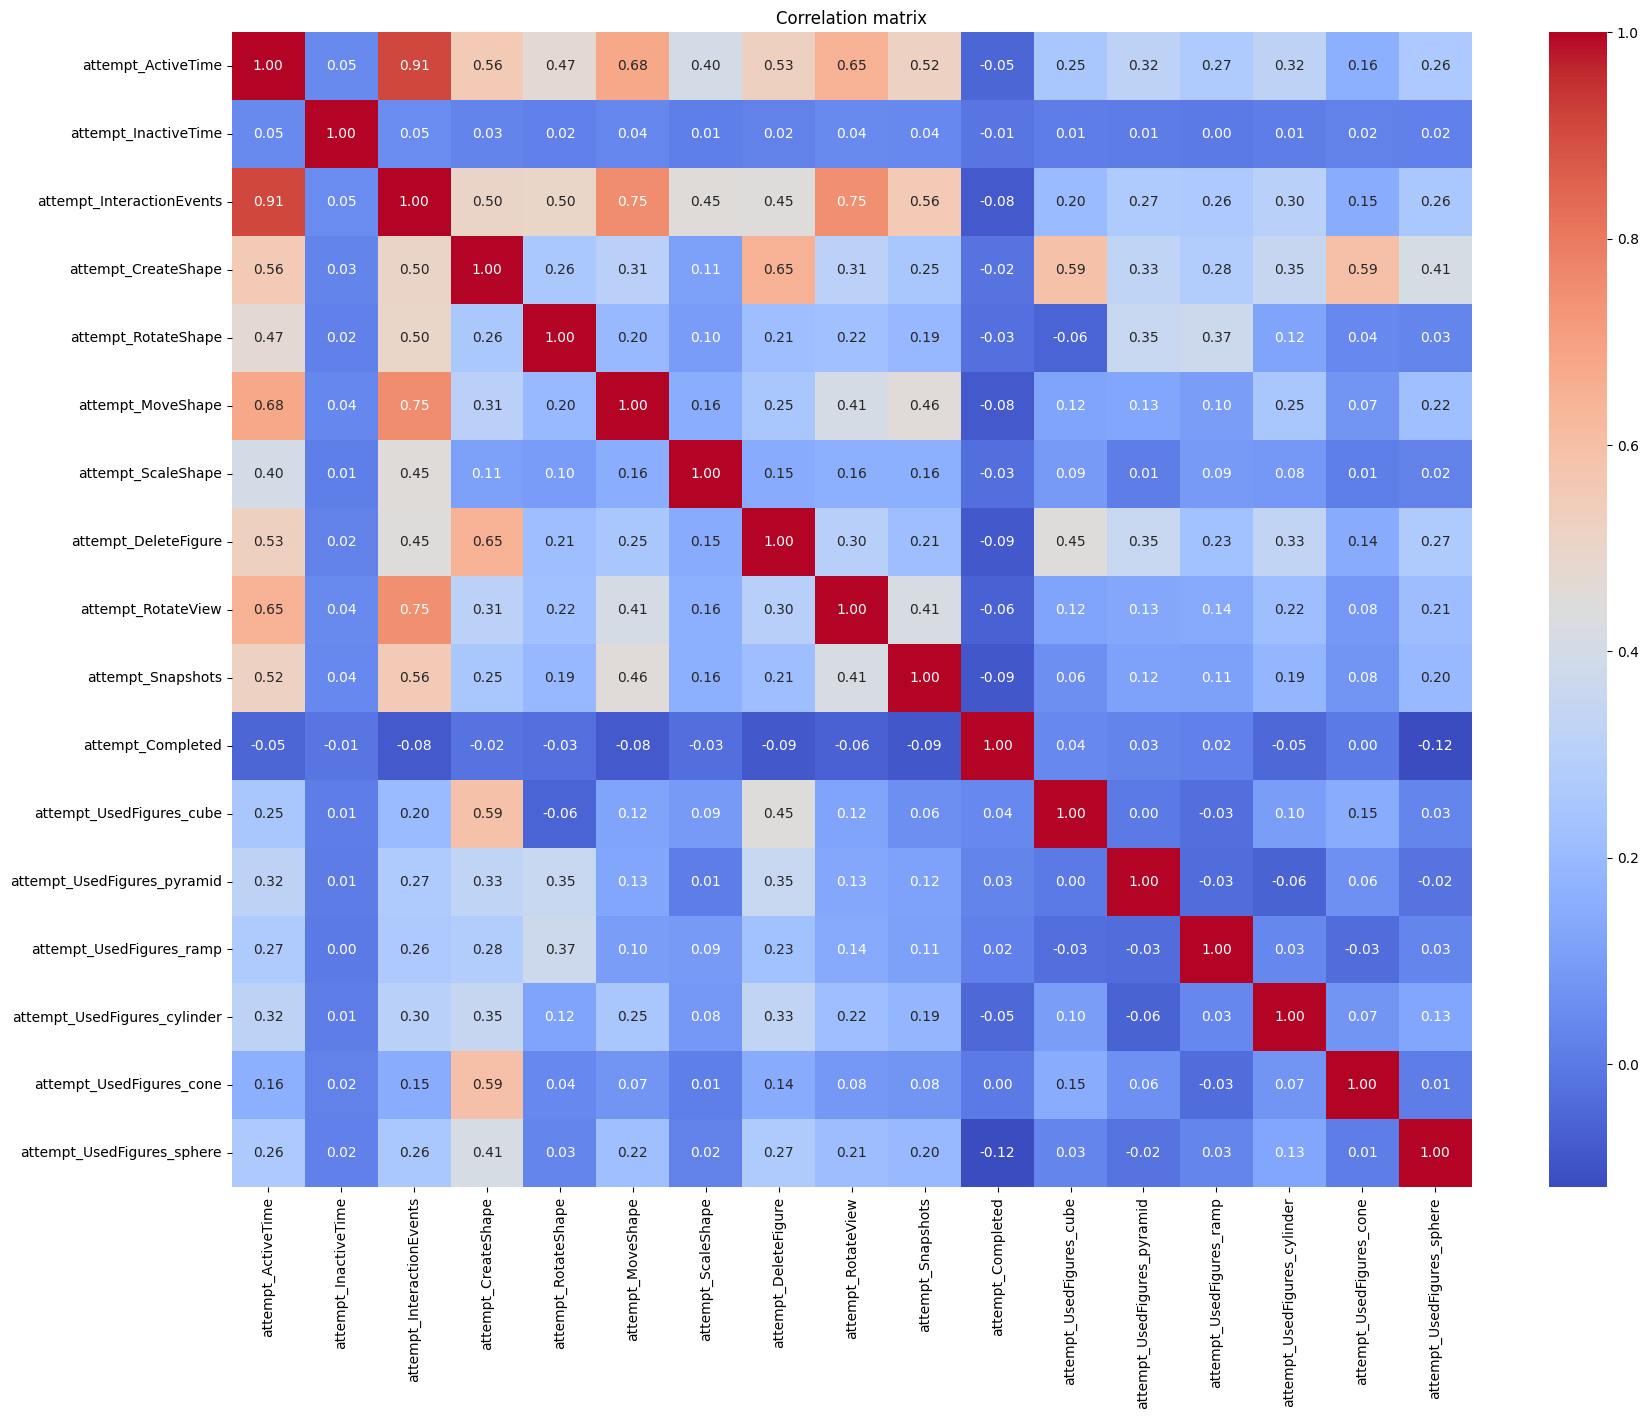

In [11]:
plt.figure(figsize=(20, 15))
sns.heatmap(df_preprocessed.select_dtypes(include=['number']).corr(),annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix")
plt.show()

Es fundamental escalar las variables numéricas para que todas tengan media 0 y desviación estándar 1, especialmente antes de aplicar muchos algoritmos de machine learning. Para garantizar una imputación correcta y evitar fugas de información, la función definida entrena el escalado solo con el conjunto de entrenamiento. La función queda declarada para ser utilizada en etapas posteriores del modelado.

In [12]:
def scale(x_train, x_test):
    scaler = StandardScaler()
    x_train = pd.DataFrame(scaler.fit_transform(x_train),columns=x_train.columns) # Solo el conjunto de train para el fit
    x_test = pd.DataFrame(scaler.transform(x_test),columns=x_test.columns)
    return x_train, x_test

Es necesario modificar las variables categóricas a OneHotEnconder, para así facilitar su uso en algoritmos de machine learning que requieren variables numéricas.

In [13]:
ohe = OneHotEncoder(drop="first", sparse_output=False, dtype=int)
encoded = ohe.fit_transform(df_preprocessed[["puzzle"]])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(["puzzle"]), index=df_preprocessed.index)

df_preprocessed = pd.concat([df_preprocessed.drop(columns=["puzzle"]), encoded_df], axis=1)

In [14]:
print(df_preprocessed.dtypes)

attempt_ActiveTime                 int64
attempt_InactiveTime               int64
attempt_InteractionEvents          int64
attempt_CreateShape                int64
attempt_RotateShape                int64
attempt_MoveShape                  int64
attempt_ScaleShape                 int64
attempt_DeleteFigure               int64
attempt_RotateView                 int64
attempt_Snapshots                  int64
attempt_Completed                  int64
attempt_UsedFigures_cube           int64
attempt_UsedFigures_pyramid        int64
attempt_UsedFigures_ramp           int64
attempt_UsedFigures_cylinder       int64
attempt_UsedFigures_cone           int64
attempt_UsedFigures_sphere         int64
puzzle_Angled Silhouette           int64
puzzle_Bear Market                 int64
puzzle_Bird Fez                    int64
puzzle_Boxes Obscure Spheres       int64
puzzle_Bull Market                 int64
puzzle_Combine 2 Ramps             int64
puzzle_Few Clues                   int64
puzzle_Match Sil

# 2. Entrenamiento con dataset completamente etiquetado (límite experimental)  <a id="2"></a>  
En este apartado se presenta el escenario de referencia del estudio: el entrenamiento utilizando el conjunto de datos completamente etiquetado. Este caso se considera el límite experimental de rendimiento, ya que se asume la disponibilidad de todas las etiquetas posibles durante el proceso de aprendizaje.

In [15]:
x_train, x_test, y_train, y_test = train_test_split(df_preprocessed.drop(columns = 'attempt_Completed'),
                                                    df_preprocessed['attempt_Completed'],
                                                    stratify = df_preprocessed['attempt_Completed'],
                                                    test_size=0.05,
                                                    random_state=GLOBAL_SEED)

# Se escala con la función creada anteriormente
x_train, x_test = scale(x_train, x_test)

# Las métricas utilizadas serán las mismas de la comparativa entre modelos, f1, precision y recall
scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
}

hyperparameters = {
                    'n_estimators': [10, 25, 50], # default: 100
                    'learning_rate': [0.3, 0.05, 0.01], # default=0.3
                    'max_depth': [3, 6, None], # default: 6
                    'min_child_weight': [1, 5] # default: 1
                  }

# Se realiza una búsqueda con validación cruzada
grid_search = GridSearchCV(XGBClassifier(random_state=GLOBAL_SEED),
                          param_grid=hyperparameters,
                          cv=5,
                          scoring=scoring,
                          refit="f1",        # Se utilizará para ajustar el mejor modelo
                          verbose=False,
                          n_jobs = 1)

grid_search.fit(x_train, y_train) # Se entrena y buscan los hiperparámetros

# Utilizaremos el mejor modelo para el cálculo de métricas
best_model = grid_search.best_estimator_

train_predict = best_model.predict(x_train)
test_predict = best_model.predict(x_test)

f1_train = f1_score(y_train, train_predict)
f1_test = f1_score(y_test, test_predict)

recall_train = recall_score(y_train, train_predict)
recall_test = recall_score(y_test, test_predict)

precision_train = precision_score(y_train, train_predict)
precision_test = precision_score(y_test, test_predict)

print(f"XGB\n" +
  f"\t F1 - Train: {f1_train:.2f} Test: {f1_test:.2f}" +
  f"\t Recall - Train: {recall_train:.2f} Test: {recall_test:.2f}" +
  f"\t Precision - Train: {precision_train:.2f} Test: {precision_test:.2f}")

XGB
	 F1 - Train: 0.94 Test: 0.89	 Recall - Train: 0.99 Test: 0.93	 Precision - Train: 0.89 Test: 0.85


Estos resultados establecen el límite superior (aproximado) de rendimiento alcanzable con la información disponible en el dataset completamente etiquetado.

# 3. Modelos clásicos de Machine Learning  <a id="3"></a>  

Para esta sección se van a entrenar los modelos de machine learning más conocidos:
1. Neural Network
2. DecisionTree
3. RandomForest
4. KNeighbours
5. SVM
6. AdaBoost
7. GradientBoosting
8. XGB


Para su entrenamiento se definirá un diccionario `hyperparameters` con el espacio de búsqueda que aplica GridSearchCV sobre los clasificadores. Para cada modelo se incluyen dinstintas configuraciones que permiten explorar distintos niveles de complejidad, desde modelos más simples (menos estimadores, menor profundidad, mayor regularización), hasta modelos más complejos (más capas, mayor número de árboles, menor regularización o mayor profundidad).

In [16]:
classifiers = [['Neural Network :', MLPClassifier()],
               ['DecisionTree :', DecisionTreeClassifier()],
               ['RandomForest :', RandomForestClassifier()],
               ['KNeighbours :', KNeighborsClassifier()],
               ['SVM :', SVC()],
               ['AdaBoost :', AdaBoostClassifier()],
               ['GradientBoosting :', GradientBoostingClassifier()],
               ['XGB :', XGBClassifier()]]

hyperparameters = {
    'Neural Network :' : {
        'hidden_layer_sizes': [(150,), (100,), (50,), (100,50), (150, 50), (100,50),  (50,50,50)], # default: (100,)
        'activation': ['relu', 'tanh'],  # default: relu
        'early_stopping': [True],
        'learning_rate': ['constant', 'adaptive'],  # default: constant
        'max_iter': [1000],
        'alpha': [0.0001, 0.001, 0.01]  # default: 0.0001
    },

    'DecisionTree :' : {
        'criterion': ['gini', 'entropy'],  # default: gini
        'max_depth': [None, 5, 7, 10],     # default: None
        'min_samples_split': [2, 10, 20],  # default: 2
        'min_samples_leaf': [1, 5, 10],    # default: 1
        "max_leaf_nodes": [None, 5, 25]    # default: None
    },

    'RandomForest :' : {
        'n_estimators': [10, 25, 30, 40],    # default: 100
        'criterion': ['gini', 'entropy'], # default: gini
        'max_depth': [None, 5, 7, 10, 15],     # default: None
        'min_samples_split': [2, 5, 10],     # default: 2
        'min_samples_leaf': [1, 2, 5],      # default: 1
        "max_leaf_nodes": [5, 10, 25, 50] # default: None
    },

    'KNeighbours :' : {
        'n_neighbors': [2, 3, 4, 5],  # default: 5
        'weights': ['uniform', 'distance'],  # default: uniform
        'algorithm': ['auto', 'ball_tree', 'kd_tree'], # default: auto
        'p': [1, 2]  # 1=Manhattan, 2=Euclidean (default)
    },

    'SVM :' : {
        'C': [0.1, 1.0, 0.1, 10],  # default: 1.0
        'kernel': ['rbf', 'linear', 'poly'],  # default: rbf
        'gamma': ['scale', 'auto', 0.01, 0.001],  # default: scale
        'degree': [3, 4]  # solo relevante para kernel='poly'
    },

    'AdaBoost :' : {
        'n_estimators': [10, 25, 50],  # default: 50
        'learning_rate': [1.0, 0.5, 0.1]  # default: 1.0
    },

    'GradientBoosting :' : {
        'n_estimators': [10, 25, 50],  # default: 100
        'learning_rate': [0.1, 0.05, 0.01],  # default: 0.1
        'max_depth': [3, 5, None], # default: 3
        "max_leaf_nodes": [None, 10, 25] # default: None
    },

    'XGB :' : {
        'n_estimators': [10, 25, 50], # default: 100
        'learning_rate': [0.3, 0.05, 0.01], # default=0.3
        'max_depth': [3, 6, None], # default: 6
        'min_child_weight': [1, 5] # default: 1
    }

}

El conjunto de datos preprocesado se divide inicialmente en entrenamiento, reservando un 5% de las muestras para evaluación final del modelo. Posteriormente, el conjunto de entrenamiento se divide para solo utilizar el 20% de los datos etiquetados

In [17]:
start_time = time.time()

x_train, x_test, y_train, y_test =  train_test_split(df_preprocessed.drop(columns = 'attempt_Completed'),
                                                    df_preprocessed['attempt_Completed'],
                                                    stratify = df_preprocessed['attempt_Completed'],
                                                    test_size=0.05,
                                                    random_state=GLOBAL_SEED)

# Se escala con la función creada anteriormente
x_train, x_test = scale(x_train, x_test)

# ~25% del total etiquetado, 5% a pruebas y el otro ~20% para entrenamiento
x_train, _, y_train, _ = train_test_split(x_train, y_train, train_size=0.22, stratify=y_train, random_state=GLOBAL_SEED)


# Las métricas utilizadas serán las mismas de la comparativa entre modelos, f1, precision y recall
scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
}

# Se entrena cada clasificador (inicializado con la semilla correspondiente) y se calculan las métricas
for name, classifier in classifiers:
    if 'random_state' in classifier.get_params():
        classifier.set_params(random_state=GLOBAL_SEED)

    # Se realiza una búsqueda con validación cruzada
    grid_search = GridSearchCV(classifier,
                              param_grid=hyperparameters[name],
                              cv=5,
                              scoring=scoring,
                              refit="f1",        # Se utilizará para ajustar el mejor modelo
                              verbose=False,
                              n_jobs = 1)

    grid_search.fit(x_train, y_train) # Se entrena y buscan los hiperparámetros

    # Utilizaremos el mejor modelo para el cálculo de métricas
    best_model = grid_search.best_estimator_

    train_predict = best_model.predict(x_train)
    test_predict = best_model.predict(x_test)

    f1_train = f1_score(y_train, train_predict)
    f1_test = f1_score(y_test, test_predict)

    recall_train = recall_score(y_train, train_predict)
    recall_test = recall_score(y_test, test_predict)

    precision_train = precision_score(y_train, train_predict)
    precision_test = precision_score(y_test, test_predict)

    print(f"{name}\n" +
      f"\t F1 - Train: {f1_train:.2f} Test: {f1_test:.2f}" +
      f"\t Recall - Train: {recall_train:.2f} Test: {recall_test:.2f}" +
      f"\t Precision - Train: {precision_train:.2f} Test: {precision_test:.2f}")

print(f"\nTiempo de entrenamiento: {int( (time.time() - start_time) // 60)} min {int( (time.time() - start_time) % 60)} seg")

Neural Network :
	 F1 - Train: 0.87 Test: 0.86	 Recall - Train: 0.91 Test: 0.86	 Precision - Train: 0.83 Test: 0.85
DecisionTree :
	 F1 - Train: 0.87 Test: 0.85	 Recall - Train: 0.93 Test: 0.89	 Precision - Train: 0.82 Test: 0.82
RandomForest :
	 F1 - Train: 0.92 Test: 0.86	 Recall - Train: 0.98 Test: 0.91	 Precision - Train: 0.86 Test: 0.82
KNeighbours :
	 F1 - Train: 1.00 Test: 0.87	 Recall - Train: 1.00 Test: 0.92	 Precision - Train: 1.00 Test: 0.82
SVM :
	 F1 - Train: 0.86 Test: 0.85	 Recall - Train: 0.91 Test: 0.87	 Precision - Train: 0.81 Test: 0.84
AdaBoost :
	 F1 - Train: 0.83 Test: 0.84	 Recall - Train: 0.95 Test: 0.95	 Precision - Train: 0.74 Test: 0.75
GradientBoosting :
	 F1 - Train: 0.91 Test: 0.88	 Recall - Train: 0.98 Test: 0.94	 Precision - Train: 0.84 Test: 0.82
XGB :
	 F1 - Train: 0.91 Test: 0.87	 Recall - Train: 0.97 Test: 0.92	 Precision - Train: 0.86 Test: 0.83

Tiempo de entrenamiento: 16 min 32 seg


Los resultados obtenidos muestran un rendimiento consistente en todos los modelos evaluados, con valores de *F1-score* en test comprendidos aproximadamente entre 0.85 y 0.88. En términos de generalización, la mayoría de modelos presentan una caída moderada entre entrenamiento y test, lo que sugiere un nivel controlado de sobreajuste. El caso más evidente es **K-Nearest Neighbours**, que muestra un comportamiento claramente sobreajustado (F1 train = 1.00 frente a 0.87 en test).

Entre los modelos con mejor equilibrio entre rendimiento y generalización destacan **Gradient Boosting** y **XGBoost**, que alcanzan los mejores resultados en test (F1 = 0.88 y 0.87 respectivamente), junto con valores de recall elevados (0.94 y 0.92), lo que indica una alta capacidad para detectar casos positivos, aunque con una precisión más moderada.

# 4. Estrategias de Active Learning <a id="4"></a>  

El conjunto de datos preprocesado se divide inicialmente en entrenamiento, reservando un 5% de las muestras para evaluación final del modelo. Posteriormente, el conjunto de entrenamiento se divide nuevamente en dos subconjuntos: un conjunto inicial etiquetado (`x_initial`, `y_initial`) y un conjunto restante o *pool* (`x_pool`, `y_pool`) destinado a las iteraciones de *Active Learning*. Las divisones se realizan de forma estratificada y reproducible mediante `random_state`.

In [18]:
x_train, x_test, y_train, y_test =  train_test_split(df_preprocessed.drop(columns = 'attempt_Completed'),
                                                    df_preprocessed['attempt_Completed'],
                                                    stratify = df_preprocessed['attempt_Completed'],
                                                    test_size=0.05,
                                                    random_state=GLOBAL_SEED)

# Se escala con la función creada anteriormente
x_train, x_test = scale(x_train, x_test)

# ~25% del total etiquetado, 5% a pruebas y ~10% para inicio de AL y el otro ~10% basadas en las queries de AL
x_initial, x_pool, y_initial, y_pool = train_test_split(x_train, y_train,
                                                        train_size=0.11, stratify=y_train, random_state=GLOBAL_SEED)

En esta sección se aplican las distintas técnicas para el proceso de *Active Learning* (*uncertainty sampling*, *diversity sampling*, *Query by committee*...).

Como la librería utilizada no implementa la estrategia `diversity_sampling`, se define una función que supla ese propósito. La función selecciona aquellas instancias del conjunto no etiquetado (`x_pool`) que se encuentran más alejadas del centroide de los datos de entrenamiento actuales del modelo. De esta manera, se priorizan ejemplos considerados más diversos o representativos de regiones poco exploradas del espacio de características. Por otro lado, la estrategia `hybrid_sampling` combina tres enfoques distintos: *uncertainty sampling*, *diversity sampling* y selección aleatoria.

Para facilitar la implementación, se define la función `active_learning`, encargada de ejecutar el ciclo iterativo de aprendizaje activo. En cada iteración, el modelo selecciona nuevas instancias del conjunto no etiquetado mediante la estrategia de consulta configurada (`model.query`). Posteriormente, dichas muestras son añadidas al conjunto de entrenamiento usando `model.teach`, y eliminadas del *pool* de datos disponibles. Tras cada actualización del modelo, se evalúa su rendimiento sobre el conjunto de prueba utilizando las métricas *F1-score*, *recall* y *precision*, almacenando los resultados obtenidos para analizar la evolución del desempeño del modelo a lo largo de las consultas realizadas.

In [19]:
def diversity_sampling(learner, x_pool, n_instances=1):
    centroid = np.mean(learner.X_training, axis=0).reshape(1, -1) # Se calcula el centroide de todo el conjunto de entrenamiento
    distances = np.linalg.norm(x_pool - centroid, axis=1) # Se calculan las distancias al centroide
    query_idx = np.argsort(distances)[-n_instances:] # Se obtienen los 'outliers'
    return query_idx, x_pool[query_idx] # Se devuelve como estrategia de diversity_sampling

def random_sampling(learner, x_pool, n_instances=1):
    query_idx = np.random.choice(range(len(x_pool)), size=n_instances, replace=False)
    return query_idx, x_pool[query_idx]

def hybrid_sampling(learner, x_pool, n_instances=1, prob_uncertainty=0.8, prob_diversity=0.1, prob_random=0.1):

    r = np.random.rand()

    if r < prob_uncertainty:
        # UNCERTAINTY
        return uncertainty_sampling(learner, x_pool, n_instances=n_instances)

    elif r < prob_uncertainty + prob_diversity:
        # DIVERSITY
        return diversity_sampling(learner, x_pool, n_instances=n_instances)

    else:
        # RANDOM
        return random_sampling(learner, x_pool, n_instances=n_instances)

# n_queries * n_instances -> instancias solicitadas
def active_learning(name, model, x_pool, y_pool, x_test, y_test, n_queries = 150,  n_instances = 5):
    x_pool = x_pool.copy()
    y_pool = y_pool.copy()

    result = {
        "f1": [],
        "recall": [],
        "precision": []
    }


    for _ in range(n_queries):
        query_idx, _ = model.query(x_pool, n_instances=n_instances) # Obtenemos n_instances en una query

        x_new = x_pool[query_idx]
        y_new = y_pool[query_idx]

        model.teach(X=x_new, y=y_new)

        x_pool = np.delete(x_pool, query_idx, axis=0)
        y_pool = np.delete(y_pool, query_idx, axis=0)

        y_pred = model.predict(x_test)
        result["f1"].append(round(f1_score(y_test, y_pred), 3))
        result["recall"].append(round(recall_score(y_test, y_pred), 3))
        result["precision"].append(round(precision_score(y_test, y_pred), 3))


    test_predict = model.predict(x_test)

    print(f"{name}:\n" +
      f"\t\t F1: {f1_score(y_test, test_predict):.2f}" +
      f"\t Recall: {recall_score(y_test, test_predict):.2f}" +
      f"\t Precision: {precision_score(y_test, test_predict):.2f}")

    return result

Se implementa el entrenamiento y evaluación de diferentes estrategias de *Active Learning* utilizando clasificadores basados principalmente en árboles de decisión. Aunque en apartados previos ya se identificó el modelo con mejor rendimiento global, se opta por emplear `RandomForest` para evitar sesgar el análisis hacia un único modelo concreto y mantener una comparación más neutral entre las distintas estrategias de consulta.

Además, se implementan dos enfoques nuevos (*Query by Committee*): un comité homogéneo compuesto por varios clasificadores `RandomForest` con diferentes semillas aleatorias, y un comité heterogéneo formado por modelos de distinta naturaleza. Ambos utilizan la estrategia `vote_entropy_sampling`, que selecciona aquellas instancias sobre las que existe mayor desacuerdo.

In [20]:
warnings.filterwarnings("ignore", category=FutureWarning) # Para evitar este warning en la celda: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite'

start_time = time.time()

# Para trabajar en numpy al igual que en los ejemplos de la librería
# https://modal-python.readthedocs.io/en/latest/content/examples/pool-based_sampling.html
x_initial = x_initial.to_numpy()
y_initial = y_initial.to_numpy()
x_pool = x_pool.to_numpy()
y_pool = y_pool.to_numpy()
x_test = x_test.to_numpy()
y_test = y_test.to_numpy()


# RANDOM
learner_random = ActiveLearner(
    estimator=RandomForestClassifier(random_state=GLOBAL_SEED),
    query_strategy=random_sampling,
    X_training=x_initial,
    y_training=y_initial
)

# UNCERTAINTY
learner_uncertainty = ActiveLearner(
    estimator=RandomForestClassifier(random_state=GLOBAL_SEED),
    query_strategy=uncertainty_sampling,
    X_training=x_initial,
    y_training=y_initial
)

# DIVERSITY
learner_diversity = ActiveLearner(
    estimator=RandomForestClassifier(random_state=GLOBAL_SEED),
    query_strategy=diversity_sampling,
    X_training=x_initial,
    y_training=y_initial
)

# HYBRID como en el libro de ROBERT (MUNRO) MONARCH
learner_hybrid = ActiveLearner(
    estimator=RandomForestClassifier(random_state=GLOBAL_SEED),
    query_strategy=hybrid_sampling,
    X_training=x_initial,
    y_training=y_initial
)

# COMMITTEE HOMOGENEOUS
committee_members_homogeneous = [
    ActiveLearner(
        estimator=RandomForestClassifier(random_state=GLOBAL_SEED),
        X_training=x_initial,
        y_training=y_initial
    )
    for i in range(4)
]

committee_homogeneous = Committee(
    learner_list=committee_members_homogeneous,
    query_strategy=vote_entropy_sampling
)


# COMMITTEE HETEROGENEOUS
committee_members_heterogeneous = []
    # XGBClassifier
xgb_learner = ActiveLearner(
    estimator=XGBClassifier(random_state=GLOBAL_SEED),
    X_training=x_initial,
    y_training=y_initial
)
committee_members_heterogeneous.append(xgb_learner)

    # Gradient Boosting
gb_learner = ActiveLearner(
    estimator=GradientBoostingClassifier(random_state=GLOBAL_SEED),
    X_training=x_initial,
    y_training=y_initial
)
committee_members_heterogeneous.append(gb_learner)

    # MLPClassifier
nn_learner = ActiveLearner(
    estimator=MLPClassifier(random_state=GLOBAL_SEED, max_iter = 1000, early_stopping = True),
    X_training=x_initial,
    y_training=y_initial
)
committee_members_heterogeneous.append(nn_learner)

    # RandomForestClassifier
rf_learner = ActiveLearner(
    estimator=RandomForestClassifier(random_state=GLOBAL_SEED),
    X_training=x_initial,
    y_training=y_initial
)
committee_members_heterogeneous.append(rf_learner)

committee_heterogeneous = Committee(
    learner_list=committee_members_heterogeneous,
    query_strategy=vote_entropy_sampling
)

results_al = {}

results_al['random'] = active_learning("random", learner_random, x_pool, y_pool, x_test, y_test)
results_al["uncertainty"] = active_learning("uncertainty", learner_uncertainty, x_pool, y_pool, x_test, y_test)
results_al["diversity"] = active_learning("diversity", learner_diversity, x_pool, y_pool, x_test, y_test)
results_al["hybrid"] = active_learning("hybrid", learner_hybrid, x_pool, y_pool, x_test, y_test)

results_al["committee_homogeneous"] = active_learning("committee_homogeneous", committee_homogeneous,
                                                      x_pool, y_pool, x_test, y_test)
results_al["committee_heterogeneous"] = active_learning("committee_heterogeneous", committee_heterogeneous,
                                                        x_pool, y_pool, x_test, y_test)


print(f"\nTiempo de entrenamiento: {int( (time.time() - start_time) // 60)} min {int( (time.time() - start_time) % 60)} seg")

warnings.resetwarnings()

random:
		 F1: 0.87	 Recall: 0.90	 Precision: 0.85
uncertainty:
		 F1: 0.89	 Recall: 0.95	 Precision: 0.84
diversity:
		 F1: 0.86	 Recall: 0.88	 Precision: 0.85
hybrid:
		 F1: 0.89	 Recall: 0.95	 Precision: 0.85
committee_homogeneous:
		 F1: 0.88	 Recall: 0.95	 Precision: 0.83
committee_heterogeneous:
		 F1: 0.90	 Recall: 0.96	 Precision: 0.84

Tiempo de entrenamiento: 11 min 43 seg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Los resultados del enfoque de Active Learning (AL) muestran un rendimiento cercano al límite teórico establecido por el entrenamiento con dataset completo, pero utilizando únicamente un subconjunto de los datos etiquetados. Se realizaron 150 consultas (n_queries = 150), en cada una de las cuales se seleccionaron 5 instancias (n_instances = 5) para etiquetar y agregar al conjunto de entrenamiento.

Se observa que las estrategias basadas en incertidumbre (uncertainty) y comité heterogéneo (committee_heterogeneous) ofrecen los mejores resultados, alcanzando F1-scores de 0.89 y 0.90 respectivamente, con valores de recall elevados (0.95/0.96), lo que indica una alta capacidad para identificar correctamente los casos positivos, aunque con una precisión algo menor.

Para analizar la evolución del rendimiento de las distintas estrategias de *Active Learning*, se genera la gráfica para el *F1-score*. El eje horizontal representa el número de consultas (*queries*) realizadas durante el proceso iterativo de aprendizaje activo, mientras que el eje vertical muestra el valor obtenido para la métrica correspondiente.

Además, se genera un segundo gráfico aplicando un suavizado para que la tendencia general de cada estrategia sea más clara y fácil de interpretar.

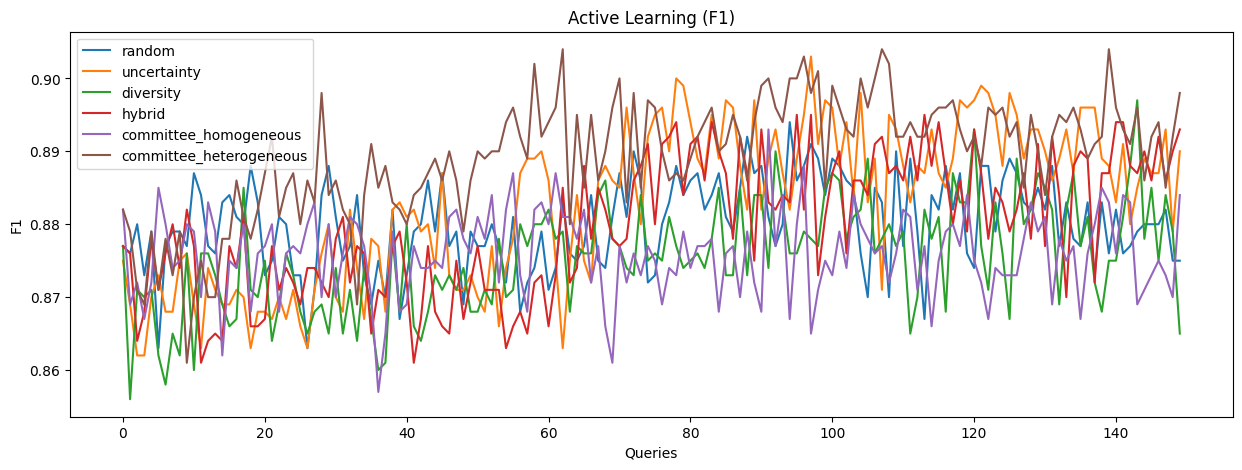

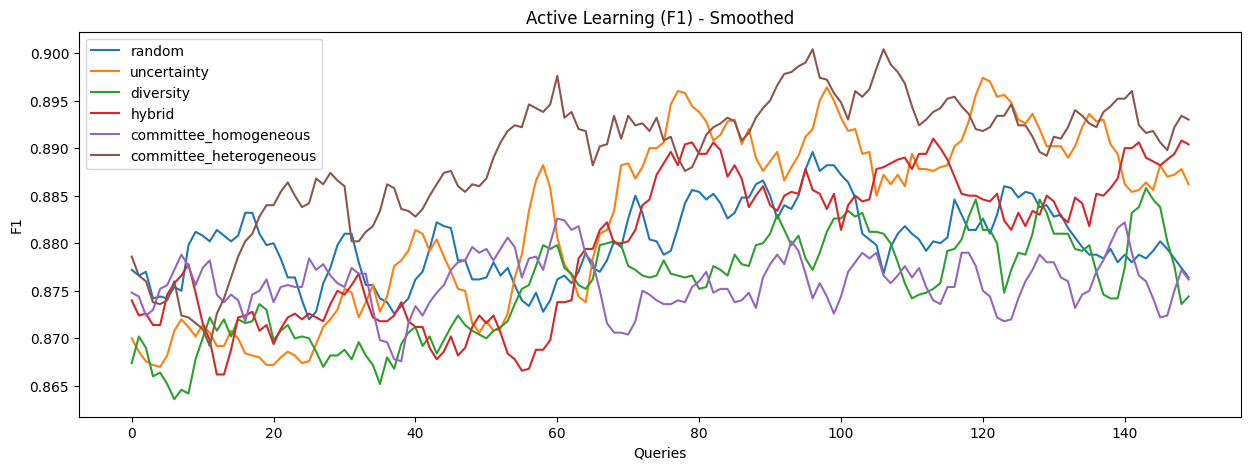

In [21]:
# Todas tienen el mismo rango de valores de queries
x = np.arange(len(results_al["uncertainty"]["f1"]))

plt.figure(figsize=(15, 5))

for key in results_al:
    plt.plot(x, results_al[key]["f1"], label=key)

plt.xlabel("Queries")
plt.ylabel("F1")
plt.title(f"Active Learning (F1)")
plt.legend()
plt.show()

plt.figure(figsize=(15, 5))

for key in results_al:
    # Suavizado de la gráfica para visualizarlo mejor
    y_smooth = uniform_filter1d(results_al[key]["f1"], size=5)

    plt.plot(x, y_smooth, label=key)

plt.xlabel("Queries")
plt.ylabel("F1")
plt.title(f"Active Learning (F1) - Smoothed")
plt.legend()
plt.show()

# 5. Fine-tuning de un modelo LLM <a id="5"></a>  

El conjunto de datos preprocesado se divide igual que en el escenario de machine learning, reservando un 5% de las muestras para evaluación y otro 20% aproximadamente para el conjunto etiquetado.

In [22]:
x_train, x_test, y_train, y_test =  train_test_split(df_preprocessed.drop(columns = 'attempt_Completed'),
                                                    df_preprocessed['attempt_Completed'],
                                                    stratify = df_preprocessed['attempt_Completed'],
                                                    test_size=0.05,
                                                    random_state=GLOBAL_SEED)

# Se escala con la función creada anteriormente
x_train, x_test = scale(x_train, x_test)

# ~25% del total etiquetado, 5% a pruebas y el otro ~20% para entrenamiento del LLM
x_initial, _, y_initial, _ = train_test_split(x_train, y_train, train_size=0.22,
                                                        stratify=y_train,
                                                        random_state=GLOBAL_SEED)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Esta sección utiliza *fine-tuning* mediante el modelo **TabPFNClassifier**, un clasificador basado en transformers diseñado para datos tabulares. Está preentrenado, por lo que solamente es necesario ajustarlo.

In [23]:
# https://huggingface.co/Prior-Labs/tabpfn_2_5 -> Uses TabPFN 2.5 weights, finetuned on real data.
clf = TabPFNClassifier(ignore_pretraining_limits=True)

start_time = time.time()
clf.fit(x_initial, y_initial)
print(f"Tiempo de entrenamiento: {int( (time.time() - start_time) // 60)} min {int( (time.time() - start_time) % 60)} seg")

# Predict labels
test_predictions = clf.predict(x_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

Tiempo de entrenamiento: 0 min 9 seg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


El modelo basado en *fine-tuning* muestra un rendimiento similar al active learning, pero teniendo en cuenta el bajo coste de entrenamiento podría ser una alternativa más eficiente.

In [24]:
f1_test = round(f1_score(y_test, test_predictions), 3)
recall_test = round(recall_score(y_test, test_predictions), 3)
precision_test = round(precision_score(y_test, test_predictions), 3)

print(f"LLM - Tabular Classification - Fine Tuning:  F1-{f1_test}  Recall-{recall_test}  Precision-{precision_test}")

LLM - Tabular Classification - Fine Tuning:  F1-0.904  Recall-0.964  Precision-0.852


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 6. Análisis de resultados y conclusiones <a id="6"></a>  

Los resultados muestran que es posible mantener un rendimiento similar con escenarios parcialmente etiquetados, destacando por poco *Active Learning* y *LLM*, logrando resultados cercanos utilizando únicamente una fracción de los datos etiquetados.

*Active Learning* destacó especialmente mediante estrategias basadas en comités, alcanzando un rendimiento similar al obtenido mediante *fine-tuning* del LLM. Esto sugiere que la selección inteligente de muestras permite maximizar la información obtenida a partir de un número reducido de ejemplos etiquetados.

No obstante, *Active Learning* requiere un proceso iterativo de reentrenamiento continuo tras cada ciclo de etiquetado, lo que incrementa la complejidad computacional. Por ello, este enfoque resulta adecuado solo en escenarios con modelos pequeños o de bajo costo computacional, donde reentrenar constantemente no representa un problema significativo. Por otro lado, el fine-tuning del LLM obtuvo un rendimiento similar con un flujo de entrenamiento más simple y sin necesidad de ciclos iterativos, convirtiéndose en una alternativa práctica para problemas más complejos.

Siguiendo esta línea, se plantea ahora utilizar el modelo LLM para la predicción temprana de si un jugador podría necesitar ayuda a mitad de la partida. Al ser un problema de mayor complejidad, dado que vamos a utilizar la traza de texto para su predicción, se opta por utilizar un modelo LLM.